# Quantum Neural Networks

A Quantum Neural Network is built for a 2D CFD problem of determining the lift coefficient for varying angles of attack, $\alpha\in[0,15\degree]$. The tutorial below shows for a single feature (soon to be extended to multiple features).

## Install Necessary Libraries

Depending the environment manager, change the first command word to "mamba"/"conda"/"micromamba" for mamba users, miniconda/anaconda users and micromamba users respectively.

In [ ]:
!conda install pandas scipy scikit-learn -c conda-forge -y

## Import Necessary Libraries

In [1]:
from NoisyCircuits import QuantumCircuit as QC
import pandas as pd
from scipy.optimize import minimize
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from NoisyCircuits.utils.CreateNoiseModel import GetNoiseModel, CreateNoiseModel
import pickle
import os
import json

2026-07-08 14:43:35,183	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


## Import and Pre-process Data

In [2]:
data = pd.read_csv("design_study_single_feature.csv", header=0)
X = data.iloc[:,0].values.reshape(-1, 1)
Y = data.iloc[:,-1].values.reshape(-1, 1)

In [3]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.4, random_state=42)

In [4]:
x_train = x_train.flatten()
x_test = x_test.flatten()
y_train = y_train.flatten()
y_test = y_test.flatten()

In [5]:
beta_x = np.linalg.norm(x_train)
beta_y = np.linalg.norm(y_train)
x_train = x_train / beta_x
y_train = y_train / beta_y
x_test = x_test / beta_x
y_test = y_test / beta_y

## Initialize Quantum Circuit Instance with Noise

In [ ]:
api_json = json.load(open(os.path.join(os.path.expanduser("~"), "ibm_api.json"), "r"))
token = api_json["apikey"] #  Replace with your IBM Quantum token
service_crn = api_json["service-crn"] # Replace with your Service CRN
backend_name = "ibm_kingston"
num_qubits = 3
num_cores = 10
num_trajectories = 100
threshold = 1e-6
jsonize = True
verbose = True
qpu_type = "heron"
sim_backend = "custom" # Choose between "custom", "pennylane", "qulacs", and "qiskit" / "custom" is the fastest option
use_fractional = True # Flag to determine whether to use fractional gates or not.

Run the code below to get the latest calibration data from IBM hardware

In [7]:
noise_model = GetNoiseModel(backend_name=backend_name, token=token, service_crn=service_crn).get_noise_model()

T1 and T2 both unreported, setting to inf (no thermal decay) for qubits: [146]


Run the code below to use a sample noise model from IBM Hardware

In [ ]:
if qpu_type == "eagle":
    file_path = "https://raw.githubusercontent.com/Sats2/NoisyCircuits/main/noise_models/Noise_Model_Eagle_QPU.pkl"
    noise_model = pickle.load(open(file_path, "rb"))
elif qpu_type == "heron":
    file_path = "https://raw.githubusercontent.com/Sats2/NoisyCircuits/main/noise_models/Sample_Noise_Model_Heron_QPU.csv"
    noise_model = CreateNoiseModel(calibration_data_file=file_path, 
                                   basis_gates=[["x", "sx", "rz", "rx"], ["cz", "rzz"]]).create_noise_model()
else:
    raise ValueError("Invalid qpu_type. Choose either 'heron' or 'eagle'.")

In [ ]:
nqc = QC(
    num_qubits = num_qubits,
    noise_model = noise_model,
    backend_qpu_type = qpu_type,
    use_fractional = use_fractional,
    sim_backend = sim_backend,
    threshold = threshold,
    verbose = verbose
)

Completed Extraction of Measurement Errors.
Completed Extraction of two-qubit gate Errors.
Starting post-processing on Single Qubit Errors.


Completed post-processing on Single Qubit Errors.
Processing two-qubit gate errors.
Qubit pair (0, 1): 18/48 errors above threshold (30 filtered out)
Qubit pair (1, 2): 18/48 errors above threshold (30 filtered out)
Qubit pair (1, 0): 18/48 errors above threshold (30 filtered out)
Qubit pair (2, 1): 18/48 errors above threshold (30 filtered out)
Qubit pair (0, 1): 18/48 errors above threshold (30 filtered out)
Qubit pair (1, 2): 18/48 errors above threshold (30 filtered out)
Qubit pair (1, 0): 18/48 errors above threshold (30 filtered out)
Qubit pair (2, 1): 18/48 errors above threshold (30 filtered out)
Two Qubit Gate errors processed.
Building Noise Operators for Two Qubit Gate Errors.
Completed building Noise Operators for Two Qubit Gate Errors.
Extracting Measurement Errors.
Preparing Qubit Connectivity Map for Requested Qubits
Qubit Connectivity Map Prepared.
Returning Single Qubit Error Instructions, Two Qubit Gate Error Instructions, Measurement Errors and Connectivity Map.


## Running the QNN

### Build Quantum Circuit for Quantum Neural Network

Here, the original circuit is modified and the single feature is embedded across $3$ qubits.

In [9]:
def quantum_circuit_pure(weights, x_value):
    # Reset the quantum circuit
    nqc.refresh()
    # Build the trainable layers
    total_layers = len(weights) // 3
    for layers in range(total_layers):
        for q in range(num_qubits):
            nqc.RY(weights[3*layers + q], qubit=q)
        for q in range(num_qubits - 1):
            nqc.CZ(control=q, target=q+1)
        for q in range(num_qubits):
            nqc.RX(x_value, qubit=q)
    # Execute the circuit
    probs = nqc.run_pure_state(qubits=list(range(num_qubits)))
    # Obtain the expectation value from the output probability distribution
    exp_val = 0.0
    for i in range(2**num_qubits):
        binary_val = bin(i)[2:].zfill(2**num_qubits)
        exp_val += probs[i] * (1 if binary_val.count("1") % 2 == 0 else -1)
    return exp_val

In [10]:
def quantum_circuit_noisy(weights, x_value):
    nqc.refresh()
    total_layers = len(weights) // 3
    # Build the trainable layers
    total_layers = len(weights) // 3
    for layers in range(total_layers):
        for q in range(num_qubits):
            nqc.RY(weights[3*layers + q], qubit=q)
        for q in range(num_qubits - 1):
            nqc.CZ(control=q, target=q+1)
        for q in range(num_qubits):
            nqc.RX(x_value, qubit=q)
    # Execute circuit
    probs = nqc.execute(
                    qubits = list(range(num_qubits)), 
                    num_trajectories = num_trajectories, 
                    num_cores = num_cores
                )
    exp_val = 0.0
    for i in range(2**num_qubits):
        binary_val = bin(i)[2:].zfill(2**num_qubits)
        exp_val += probs[i] * (1 if binary_val.count("1") % 2 == 0 else -1)
    return exp_val

### Define Functions

Next we define the functions for predictions, loss function and accuracy functions

In [11]:
def predict(circuit_builder:callable,
            x_array:np.ndarray,
            weights:np.ndarray)->np.ndarray:
    predictions = [circuit_builder(weights, x) for x in x_array]
    return np.array(predictions)

def loss_function(circuit_builder:callable,
                  x_array:np.ndarray=x_train,
                  y_array:np.ndarray=y_train,
                  weights:np.ndarray=None)->float:
    predictions = predict(circuit_builder, x_array, weights)
    cost_mse = np.mean((predictions - y_array) ** 2) * beta_y**2
    return cost_mse

def accuracy_function(circuit_builder:callable,
                      x_array:np.ndarray=x_test,
                      y_array:np.ndarray=y_test,
                      weights:np.ndarray=None)->list[float]:
    predictions = predict(circuit_builder, x_array, weights) * beta_y
    rmse = root_mean_squared_error(y_array*beta_y, predictions)
    r2 = r2_score(y_array*beta_y, predictions)
    return [rmse, r2]

In [12]:
def cost_function(circuit_builder:callable,
                  weights_init:np.ndarray,
                  max_iter:int=100)->tuple[np.ndarray, list, list]:
    cost_list = []
    accuracy_list = []

    def objective(weights:np.ndarray,
                circuit_builder:callable)->float:
        global iteration
        loss = loss_function(circuit_builder, weights=weights)
        accuracy = accuracy_function(circuit_builder, weights=weights)
        iteration += 1
        print(f"Epoch: {iteration}\tLoss: {loss}\tRMSE: {accuracy[0]}\tR2: {accuracy[1]}")
        cost_list.append(loss)
        accuracy_list.append(accuracy)
        return loss
    
    opt = minimize(objective, x0=weights_init,
                   args=(circuit_builder,),
                   method="COBYLA", options={"maxiter": max_iter})
    weights = opt.x
    return (weights, cost_list, accuracy_list)

## Run the QNN

In [15]:
max_iter = 100
num_layers = 4
weights_init = np.random.uniform(-2*np.pi, 2*np.pi, size=(num_qubits*num_layers))

### Run the QNN with Pure Statevector Simulation

In [16]:
iteration = 0
weights_pure, cost_list_pure, accuracy_list_pure = cost_function(circuit_builder=quantum_circuit_pure,  
                                                                 weights_init=weights_init, 
                                                                 max_iter=max_iter)

Epoch: 1	Loss: 3.4569749817679627	RMSE: 1.771459809246949	R2: -10.017226783901833
Epoch: 2	Loss: 1.469448237231295	RMSE: 1.1410074280518334	R2: -3.5707411349749503
Epoch: 3	Loss: 5.643031913978019	RMSE: 2.2716678523916918	R2: -17.117544906648266
Epoch: 4	Loss: 0.21420824622628445	RMSE: 0.5312661168347744	R2: 0.009090667264525565
Epoch: 5	Loss: 0.8233884376289526	RMSE: 0.9518167187506634	R2: -2.180653356329543
Epoch: 6	Loss: 0.11093441474519482	RMSE: 0.3564842947682759	R2: 0.5538401505526687
Epoch: 7	Loss: 0.20107799298529536	RMSE: 0.4552748162986117	R2: 0.27229235446427225
Epoch: 8	Loss: 0.24910983554057164	RMSE: 0.5596869748445712	R2: -0.0997654762772735
Epoch: 9	Loss: 0.4849125309636145	RMSE: 0.7801934887749746	R2: -1.1370482376596671
Epoch: 10	Loss: 1.8866519400030979	RMSE: 1.2977876666029202	R2: -4.913123740310798
Epoch: 11	Loss: 1.2944267635587965	RMSE: 1.038380243721702	R2: -2.7854935925737228
Epoch: 12	Loss: 1.4021044949120003	RMSE: 1.229865581958603	R2: -4.310372400153684
Epoch

### Run the QNN with MCWF Method for Noisy Simulation

In [17]:
iteration = 0
weights_noisy, cost_list_noisy, accuracy_list_noisy = cost_function(circuit_builder=quantum_circuit_noisy,
                                                                    weights_init=weights_init,
                                                                    max_iter=max_iter)

Epoch: 1	Loss: 3.3265517770329485	RMSE: 1.7395276102104762	R2: -9.623615279802255
Epoch: 2	Loss: 1.4000236274276021	RMSE: 1.1014563146719962	R2: -3.2593589042156763
Epoch: 3	Loss: 5.255564491118962	RMSE: 2.1880967186516735	R2: -15.809032305828914
Epoch: 4	Loss: 0.09583186637824409	RMSE: 0.38738691511682066	R2: 0.4731347236522241
Epoch: 5	Loss: 0.4869473879524235	RMSE: 0.7486784119717259	R2: -0.9678876633910951
Epoch: 6	Loss: 0.07737456313846562	RMSE: 0.2652885216495177	R2: 0.7529148747042753
Epoch: 7	Loss: 0.265380052510231	RMSE: 0.5291238985669761	R2: 0.017065820389858932
Epoch: 8	Loss: 0.1537716153333815	RMSE: 0.4272101634073947	R2: 0.35924377460850865
Epoch: 9	Loss: 0.2864931987819326	RMSE: 0.6019207694155224	R2: -0.27200359928852835
Epoch: 10	Loss: 1.8057059316697355	RMSE: 1.2725639721774118	R2: -4.685503477727457
Epoch: 11	Loss: 1.3447766117938484	RMSE: 1.0617930594649034	R2: -2.958124464071473
Epoch: 12	Loss: 1.0302017343843326	RMSE: 1.0714489767200361	R2: -3.030441955145786
Epoc

## Visualize the Results

### Pre-Processing Training and Validation Data

1. Segregate the different metrics for quick and easy visualization.
2. Cap the values of the $R^2$ Score to lie between $[-1,1]$ for clean visualization, where an $R^2$ Score of $-1$. 

In [18]:
accuracy_data_pure = np.array(accuracy_list_pure)
accuracy_data_noisy = np.array(accuracy_list_noisy)
cost_data_pure = np.array(cost_list_pure)
cost_data_noisy = np.array(cost_list_noisy)
rmse_pure = accuracy_data_pure[:,0]
rmse_noisy = accuracy_data_noisy[:,0]
r2_score_pure = accuracy_data_pure[:,1]
r2_score_noisy = accuracy_data_noisy[:,1]
r2_score_pure_filtered = np.clip(r2_score_pure, -1, 1)
r2_score_noisy_filtered = np.clip(r2_score_noisy, -1, 1)
epoch_list = np.arange(1, max_iter+1, 1, dtype=int)

### Visualize the Data

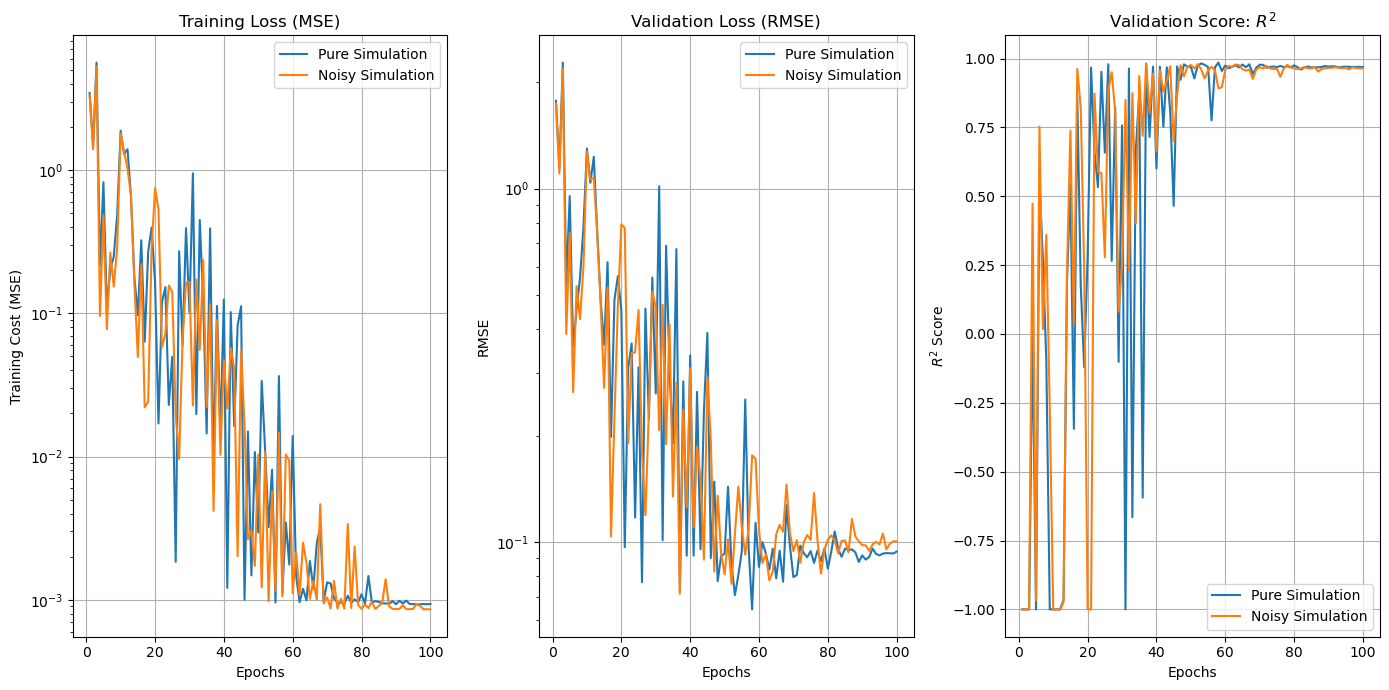

In [19]:
fig, ax = plt.subplots(1,3, figsize=(14,7))
for i, metric in enumerate(zip([cost_data_pure, rmse_pure, r2_score_pure_filtered], [cost_data_noisy, rmse_noisy, r2_score_noisy_filtered])):
    if i == 2:
        ax[i].plot(epoch_list, metric[0], label="Pure Simulation")
        ax[i].plot(epoch_list, metric[1], label="Noisy Simulation")
    else:
        ax[i].semilogy(epoch_list, metric[0], label="Pure Simulation")
        ax[i].semilogy(epoch_list, metric[1], label="Noisy Simulation")
    ax[i].set_xlabel("Epochs")
    ax[i].set_ylabel(["Training Cost (MSE)", "RMSE", "$R^2$ Score"][i])
    ax[i].set_title(["Training Loss (MSE)", "Validation Loss (RMSE)", "Validation Score: $R^2$"][i])
    ax[i].legend()
    ax[i].grid()
plt.tight_layout()
plt.show()

## Run On Hardware

In [20]:
from NoisyCircuits.RunOnHardware import RunOnHardware
import time

In [21]:
shots = 20000
hardware_runner = RunOnHardware(
    token=token,
    backend=backend_name,
    shots=shots
)

qiskit_runtime_service._discover_account:WARNING:2026-07-08 14:46:30,913: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-07-08 14:46:33,246: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: Open_Sys. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-07-08 14:46:33,248: Loading instance: Open_Sys, plan: open


In [22]:
def build_circuit_for_network(weights, x_value):
    nqc.refresh()
    total_layers = len(weights) // 3
    # Build the trainable layers
    total_layers = len(weights) // 3
    for layers in range(total_layers):
        for q in range(num_qubits):
            nqc.RY(weights[3*layers + q], qubit=q)
        for q in range(num_qubits - 1):
            nqc.CZ(control=q, target=q+1)
        for q in range(num_qubits):
            nqc.RX(x_value, qubit=q)

In [ ]:
def submit_job(weights):
    hardware_runner.reset_circuits()
    for x in x_test:
        build_circuit_for_network(weights, x)
        hardware_runner.create_circuits(nqc, measure_qubits=list(range(num_qubits)))
    hardware_runner.setup_circuits()
    job_id = hardware_runner.run()
    keep_running = True
    while keep_running:
        time.sleep(5)
        if hardware_runner.status() == "DONE":
            probs_hardware_list = hardware_runner.get_results()
            keep_running = False
    return probs_hardware_list

In [24]:
probs_pure = submit_job(weights_pure)

qiskit_runtime_service.backends:WARNING:2026-07-08 14:46:59,526: Using instance: Open_Sys, plan: open


qiskit_runtime_service.backends:WARNING:2026-07-08 14:47:02,039: Using instance: Open_Sys, plan: open
qiskit_runtime_service.backends:WARNING:2026-07-08 14:47:02,993: Using instance: Open_Sys, plan: open
qiskit_runtime_service.backends:WARNING:2026-07-08 14:47:04,021: Using instance: Open_Sys, plan: open
qiskit_runtime_service.backends:WARNING:2026-07-08 14:47:05,054: Using instance: Open_Sys, plan: open
qiskit_runtime_service.backends:WARNING:2026-07-08 14:47:05,940: Using instance: Open_Sys, plan: open
qiskit_runtime_service.backends:WARNING:2026-07-08 14:47:06,678: Using instance: Open_Sys, plan: open
qiskit_runtime_service.backends:WARNING:2026-07-08 14:47:07,422: Using instance: Open_Sys, plan: open


Job ID: d974dl8tcv6s73dkg3sg


In [25]:
probs_noisy = submit_job(weights_noisy)

qiskit_runtime_service.backends:WARNING:2026-07-08 15:00:52,834: Using instance: Open_Sys, plan: open
qiskit_runtime_service.backends:WARNING:2026-07-08 15:00:53,646: Using instance: Open_Sys, plan: open
qiskit_runtime_service.backends:WARNING:2026-07-08 15:00:55,087: Using instance: Open_Sys, plan: open
qiskit_runtime_service.backends:WARNING:2026-07-08 15:00:56,155: Using instance: Open_Sys, plan: open
qiskit_runtime_service.backends:WARNING:2026-07-08 15:00:56,902: Using instance: Open_Sys, plan: open
qiskit_runtime_service.backends:WARNING:2026-07-08 15:00:57,591: Using instance: Open_Sys, plan: open
qiskit_runtime_service.backends:WARNING:2026-07-08 15:00:58,352: Using instance: Open_Sys, plan: open
qiskit_runtime_service.backends:WARNING:2026-07-08 15:00:59,375: Using instance: Open_Sys, plan: open


Job ID: d974k5cqp3as739raja0


In [26]:
def get_hardware_prediction(probs_list):
    predictions = []
    for prob in probs_list:
        pred = 0.0
        for i in range(len(prob)):
            binary_val = bin(i)[2:].zfill(2**num_qubits)
            pred += prob[i] * (1 if binary_val.count("1") % 2 == 0 else -1)
        predictions.append(pred)
    return np.array(predictions)

In [27]:
def validate_hardware_results(prediction):
    rmse = root_mean_squared_error(y_test*beta_y, prediction*beta_y)
    r2 = r2_score(y_test*beta_y, prediction*beta_y)
    return [rmse, r2]

In [29]:
predictions_pure = get_hardware_prediction(probs_pure)
validation_metrics_pure = validate_hardware_results(predictions_pure)
print("Validation Metrics:\nNRMSE: {:.4f}\tR2 Score: {:.4f}".format(validation_metrics_pure[0], validation_metrics_pure[1]))

Validation Metrics:
NRMSE: 0.2973	R2 Score: 0.6896


In [30]:
predictions_noisy = get_hardware_prediction(probs_noisy)
validation_metrics_noisy = validate_hardware_results(predictions_noisy)
print("Validation Metrics:\nNRMSE: {:.4f}\tR2 Score: {:.4f}".format(validation_metrics_noisy[0], validation_metrics_noisy[1]))

Validation Metrics:
NRMSE: 0.1473	R2 Score: 0.9238


In [32]:
probs_noisy_after_while = submit_job(weights_noisy)
predictions_noisy_after_while = get_hardware_prediction(probs_noisy_after_while)
validation_metrics_noisy_after_while = validate_hardware_results(predictions_noisy_after_while)
print("Validation Metrics:\nNRMSE: {:.4f}\tR2 Score: {:.4f}".format(validation_metrics_noisy_after_while[0], validation_metrics_noisy_after_while[1]))

qiskit_runtime_service.backends:WARNING:2026-07-08 15:39:04,561: Using instance: Open_Sys, plan: open
qiskit_runtime_service.backends:WARNING:2026-07-08 15:39:06,608: Using instance: Open_Sys, plan: open
qiskit_runtime_service.backends:WARNING:2026-07-08 15:39:07,589: Using instance: Open_Sys, plan: open
qiskit_runtime_service.backends:WARNING:2026-07-08 15:39:08,270: Using instance: Open_Sys, plan: open
qiskit_runtime_service.backends:WARNING:2026-07-08 15:39:09,179: Using instance: Open_Sys, plan: open
qiskit_runtime_service.backends:WARNING:2026-07-08 15:39:10,037: Using instance: Open_Sys, plan: open
qiskit_runtime_service.backends:WARNING:2026-07-08 15:39:10,842: Using instance: Open_Sys, plan: open
qiskit_runtime_service.backends:WARNING:2026-07-08 15:39:11,760: Using instance: Open_Sys, plan: open


Job ID: d97562gtcv6s73dkgv70
Validation Metrics:
NRMSE: 0.1166	R2 Score: 0.9523
